In [14]:
import pandas as pd

df = pd.read_csv('player_stats.csv')
df.head()

,player,position,rating,total_remates,xG,passes_certos,toques,toques_area_adv,dribles,duelos,match_id,home,away,score
0,Larrazabal G.,Médio ofensivo,8.3,1,0.31,8/17 (47%),46,3,0/2 (0%),5,IcJBYh6e,Casa Pia AC,Torreense,2-0
1,Kaly,Defesa-central,8.1,1,0.21,17/18 (94%),38,-,1/1 (100%),11,IcJBYh6e,Casa Pia AC,Torreense,2-0
2,Ofori L.,Médio,7.8,1,0.91,16/18 (89%),29,2,-,5,IcJBYh6e,Casa Pia AC,Torreense,2-0
3,Prieto K.,Ala,7.8,2,0.03,13/18 (72%),45,1,1/2 (50%),14,IcJBYh6e,Casa Pia AC,Torreense,2-0
4,Geraldes A.,Ala,7.6,-,-,23/28 (82%),56,-,2/3 (67%),7,IcJBYh6e,Casa Pia AC,Torreense,2-0


In [15]:
import re

def parse_ratio(val):
    if pd.isna(val) or val == '-':
        return float('nan')
    m = re.search(r'\((\d+)%\)', str(val))
    return float(m.group(1)) if m else float('nan')

df.replace('-', float('nan'), inplace=True)

df['passes_certos_pct'] = df['passes_certos'].apply(parse_ratio)
df['dribles_pct']       = df['dribles'].apply(parse_ratio)
df['duelos_pct']        = df['duelos'].apply(parse_ratio)

df['xG']            = pd.to_numeric(df['xG'], errors='coerce')
df['total_remates'] = pd.to_numeric(df['total_remates'], errors='coerce')
df['rating']        = pd.to_numeric(df['rating'], errors='coerce')
df['toques']        = pd.to_numeric(df['toques'], errors='coerce')
df['toques_area_adv'] = pd.to_numeric(df['toques_area_adv'], errors='coerce')

df[['passes_certos_pct', 'dribles_pct', 'duelos_pct', 'xG', 'rating']].head()


,passes_certos_pct,dribles_pct,duelos_pct,xG,rating
0,47.0,0.0,NaN,0.31,8.3
1,94.0,100.0,NaN,0.21,8.1
2,89.0,NaN,NaN,0.91,7.8
3,72.0,50.0,NaN,0.03,7.8
4,82.0,67.0,NaN,NaN,7.6


In [16]:
def score_to_result(score):
    h, a = map(int, score.split('-'))
    if h > a:   return 'H'
    elif h < a: return 'A'
    else:       return 'D'

df['result']       = df['score'].apply(score_to_result)
df['position_enc'] = df['position'].astype('category').cat.codes

print(df['result'].value_counts())
df[['player', 'position', 'position_enc', 'result']].head()


result
H    4007
A    3044
D    2611
Name: count, dtype: int64


,player,position,position_enc,result
0,Larrazabal G.,Médio ofensivo,11,H
1,Kaly,Defesa-central,3,H
2,Ofori L.,Médio,10,H
3,Prieto K.,Ala,0,H
4,Geraldes A.,Ala,0,H


In [17]:
from sklearn.model_selection import GroupShuffleSplit

feature_cols = [
    'rating', 'xG', 'total_remates',
    'passes_certos_pct', 'toques', 'toques_area_adv',
    'dribles_pct', 'duelos_pct', 'position_enc'
]

X      = df[feature_cols].fillna(0)
y      = df['result']
groups = df['match_id']

# split por match_id para evitar data leakage (jogadores do mesmo jogo só num split)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)} jogadores | Test: {len(X_test)} jogadores")
print(f"Jogos no teste: {df['match_id'].iloc[test_idx].nunique()}")


Train: 7718 jogadores | Test: 1944 jogadores
Jogos no teste: 62


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, preds):.3f}")
    print(classification_report(y_test, preds))


=== Logistic Regression ===
Accuracy: 0.433
              precision    recall  f1-score   support

           A       0.29      0.04      0.07       505
           D       0.27      0.03      0.05       589
           H       0.44      0.95      0.60       850

    accuracy                           0.43      1944
   macro avg       0.34      0.34      0.24      1944
weighted avg       0.35      0.43      0.30      1944

=== Random Forest ===
Accuracy: 0.373
              precision    recall  f1-score   support

           A       0.25      0.28      0.26       505
           D       0.34      0.19      0.25       589
           H       0.45      0.55      0.50       850

    accuracy                           0.37      1944
   macro avg       0.35      0.34      0.34      1944
weighted avg       0.37      0.37      0.36      1944



In [19]:
try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc  = le.transform(y_test)

    xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss', verbosity=0)
    xgb.fit(X_train, y_train_enc)
    preds_xgb = le.inverse_transform(xgb.predict(X_test))

    print("=== XGBoost ===")
    print(f"Accuracy: {accuracy_score(y_test, preds_xgb):.3f}")
    print(classification_report(y_test, preds_xgb))
except ImportError:
    print("xgboost não instalado. Corre: pip install xgboost")


=== XGBoost ===
Accuracy: 0.379
              precision    recall  f1-score   support

           A       0.28      0.30      0.29       505
           D       0.32      0.20      0.25       589
           H       0.45      0.55      0.50       850

    accuracy                           0.38      1944
   macro avg       0.35      0.35      0.34      1944
weighted avg       0.37      0.38      0.37      1944



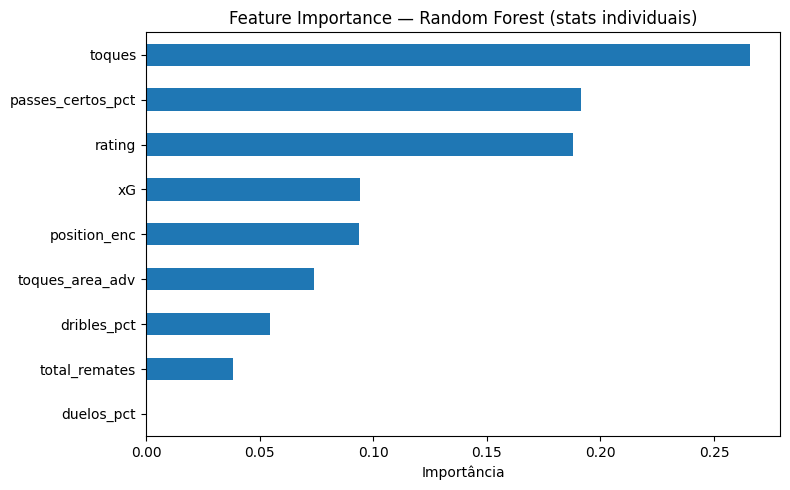

In [20]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('Feature Importance — Random Forest (stats individuais)')
plt.xlabel('Importância')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [21]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

groups_train = df['match_id'].iloc[train_idx].values
cv_group     = GroupKFold(n_splits=5)

# --- Logistic Regression ---
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced']},
    cv=cv_group, scoring='accuracy', n_jobs=-1
)
lr_gs.fit(X_train, y_train, groups=groups_train)
print(f"LR   best: {lr_gs.best_params_}  |  CV acc: {lr_gs.best_score_:.3f}")

# --- Random Forest ---
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators':    [100, 300],
        'max_depth':       [None, 10, 20],
        'min_samples_split': [2, 5],
        'max_features':    ['sqrt', 'log2'],
    },
    cv=cv_group, scoring='accuracy', n_jobs=-1
)
rf_gs.fit(X_train, y_train, groups=groups_train)
print(f"RF   best: {rf_gs.best_params_}  |  CV acc: {rf_gs.best_score_:.3f}")

# --- XGBoost (labels têm de ser inteiros) ---
le_gs          = LabelEncoder()
y_train_enc_gs = le_gs.fit_transform(y_train)
y_test_enc_gs  = le_gs.transform(y_test)

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    {
        'n_estimators':  [100, 300],
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.3],
        'subsample':     [0.8, 1.0],
    },
    cv=cv_group, scoring='accuracy', n_jobs=-1
)
xgb_gs.fit(X_train, y_train_enc_gs, groups=groups_train)
print(f"XGB  best: {xgb_gs.best_params_}  |  CV acc: {xgb_gs.best_score_:.3f}")


LR   best: {'C': 0.01, 'class_weight': None}  |  CV acc: 0.405
RF   best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}  |  CV acc: 0.393
XGB  best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}  |  CV acc: 0.402


In [22]:
import joblib

lr_acc  = accuracy_score(y_test,         lr_gs.best_estimator_.predict(X_test))
rf_acc  = accuracy_score(y_test,         rf_gs.best_estimator_.predict(X_test))
xgb_acc = accuracy_score(y_test_enc_gs, xgb_gs.best_estimator_.predict(X_test))

print("=== Test Accuracy após GridSearch ===")
print(f"  Logistic Regression : {lr_acc:.3f}  (era 0.433)")
print(f"  Random Forest       : {rf_acc:.3f}  (era 0.373)")
print(f"  XGBoost             : {xgb_acc:.3f}  (era 0.379)")

scores    = {'Logistic Regression': lr_acc, 'Random Forest': rf_acc, 'XGBoost': xgb_acc}
best_name = max(scores, key=scores.get)
print(f"\nMelhor modelo: {best_name} ({scores[best_name]:.3f})")

if best_name == 'XGBoost':
    best_estimator = xgb_gs.best_estimator_
    label_enc      = le_gs
elif best_name == 'Random Forest':
    best_estimator = rf_gs.best_estimator_
    label_enc      = None
else:
    best_estimator = lr_gs.best_estimator_
    label_enc      = None

# 'classes' é sempre ['A','D','H'] — LR/RF guardam strings, XGB usa LabelEncoder mas a ordem é igual (alfabética)
model_bundle = {
    'model':         best_estimator,
    'label_encoder': label_enc,
    'feature_cols':  feature_cols,
    'classes':       ['A', 'D', 'H'],
    'model_name':    best_name,
}
joblib.dump(model_bundle, 'best_model.pkl')
print("Modelo guardado em best_model.pkl")


=== Test Accuracy após GridSearch ===
  Logistic Regression : 0.436  (era 0.433)
  Random Forest       : 0.433  (era 0.373)
  XGBoost             : 0.423  (era 0.379)

Melhor modelo: Logistic Regression (0.436)
Modelo guardado em best_model.pkl


In [23]:
# Perfil médio histórico de cada jogador
player_profiles = (
    df.groupby('player')[feature_cols]
    .mean()
    .reset_index()
)

print(f"{len(player_profiles)} jogadores únicos no dataset")
player_profiles.head()


579 jogadores únicos no dataset


,player,rating,xG,total_remates,passes_certos_pct,toques,toques_area_adv,dribles_pct,duelos_pct,position_enc
0,Abascal R.,7.003846,0.080000,1.153846,83.333333,66.296296,1.200000,60.000000,NaN,2.962963
1,Abbey N.,6.532000,0.026667,1.000000,82.000000,54.307692,1.800000,56.250000,NaN,4.653846
2,Abdulai S.,6.200000,0.034286,1.571429,82.000000,35.588235,1.500000,61.833333,NaN,10.000000
3,Abubakar U.,6.636364,0.340909,1.636364,53.750000,7.727273,2.066667,20.000000,NaN,1.000000
4,Adriano Firmino,6.300000,0.060000,1.166667,87.111111,51.888889,1.250000,61.133333,NaN,10.000000


In [24]:
def predict_match(home_players, away_players, bundle=None):
    """
    home_players: lista com 11 nomes (equipa da casa)
    away_players: lista com 11 nomes (equipa de fora)
    bundle: dict com 'model', 'feature_cols', 'classes' (carregado de best_model.pkl por defeito)
    """
    if bundle is None:
        bundle = joblib.load('best_model.pkl')

    model     = bundle['model']
    feat_cols = bundle['feature_cols']
    classes   = bundle['classes']   # sempre ['A', 'D', 'H']

    rows, not_found = [], []
    for name in home_players + away_players:
        profile = player_profiles[player_profiles['player'] == name]
        if profile.empty:
            not_found.append(name)
            rows.append({f: 0.0 for f in feat_cols})
        else:
            rows.append(profile[feat_cols].fillna(0).iloc[0].to_dict())

    if not_found:
        print(f"Jogadores não encontrados (usando médias 0): {not_found}")

    probas   = model.predict_proba(pd.DataFrame(rows)[feat_cols])
    avg_prob = probas.mean(axis=0)
    result   = {cls: round(p * 100, 1) for cls, p in zip(classes, avg_prob)}

    print(f"[{bundle['model_name']}]")
    print(f"\nCasa:  {', '.join(home_players)}")
    print(f"Fora:  {', '.join(away_players)}")
    print(f"\n  Vitória Casa (H): {result.get('H', 0):.1f}%")
    print(f"  Empate       (D): {result.get('D', 0):.1f}%")
    print(f"  Vitória Fora (A): {result.get('A', 0):.1f}%")
    return result


# --- Exemplo ---
home_11 = player_profiles['player'].sample(11, random_state=1).tolist()
away_11 = player_profiles['player'].sample(11, random_state=2).tolist()

predict_match(home_11, away_11)


[Logistic Regression]

Casa:  Goulart J., Pizzi, Moutinho J., Pepê, Scholze M., Zalazar R., Pote, Pietuszewski O., Semedo L., Jovane, Gabriel Batista
Fora:  Buta L., van Ee E., Gomez V., Matheus Dias, Novais J., Gouveia T., Pinto D., Nhaga R., Meireles J., Gabriel Batista, Kassary Z.

  Vitória Casa (H): 39.9%
  Empate       (D): 26.7%
  Vitória Fora (A): 33.4%


{'A': np.float64(33.4), 'D': np.float64(26.7), 'H': np.float64(39.9)}